# Urnes de Pólya — Étude expérimentale de la domination trajectorielle

## Contexte

Les urnes de Pólya constituent un modèle fondamental de processus stochastiques à renforcement, introduit dans les années 1920. Elles illustrent des phénomènes de dépendance temporelle et de feedback positif.

## Objectif

On s’intéresse à la question suivante :

> Une couleur initialement dominante peut-elle rester strictement dominante à tout instant ?

Formellement, si l’on note $(B_n, W_n)$ le nombre de boules noires et blanches après \( n \) tirages, on étudie l’événement :
$$
A = \{ \forall n \ge 0,\; B_n > W_n \}
$$

L’objectif de ce notebook est :
- de **modéliser le processus**,
- de **simuler son évolution**,
- d’**estimer empiriquement** la probabilité de cet événement,
- et de **préparer l’analyse théorique** associée.

Ce notebook constitue une étude expérimentale rigoureuse du modèle, visant à développer une intuition probabiliste et à illustrer les résultats théoriques, sans constituer une démonstration formelle.

In [2]:
import numpy as np

def simulate_polya(b0: int, w0: int, mb: int, mw: int, n_steps: int, seed=None):
    """
    Simule une urne de Pólya à deux couleurs.
    
    Paramètres :
    - b0, w0 : conditions initiales
    - mb, mw : paramètres de renforcement
    - n_steps : nombre d'itérations
    """
    if seed is not None:
        np.random.seed(seed)
    
    B = np.zeros(n_steps + 1, dtype=int)
    W = np.zeros(n_steps + 1, dtype=int)
    
    B[0], W[0] = b0, w0
    
    for n in range(n_steps):
        total = B[n] + W[n]
        p_black = B[n] / total
        
        if np.random.rand() < p_black:
            B[n+1] = B[n] + mb + 1
            W[n+1] = W[n]
        else:
            B[n+1] = B[n]
            W[n+1] = W[n] + mw + 1
    
    return B, W

## Modèle probabiliste

On considère une urne contenant des boules de deux couleurs : noir et blanc.

### Conditions initiales

$$
B_0 = b_0 > 0, \quad W_0 = w_0 > 0
$$

### Dynamique

À chaque étape $n \ge 0$ :

1. On tire une boule uniformément :

$$
P(\text{tirer noir} \mid \mathcal{F}_n) = \frac{B_n}{B_n + W_n}
$$

2. On remet la boule tirée, ainsi que $m_i$ nouvelles boules de même couleur :

$$
(B_{n+1}, W_{n+1}) =
\begin{cases}
(B_n + m_b + 1, W_n) & \text{si noir} \\
(B_n, W_n + m_w + 1) & \text{si blanc}
\end{cases}
$$

### Structure mathématique

- Processus de Markov homogène
- Renforcement dépendant de la couleur
- Croissance non bornée (processus explosif)

Ce modèle induit une dépendance forte entre passé et futur.

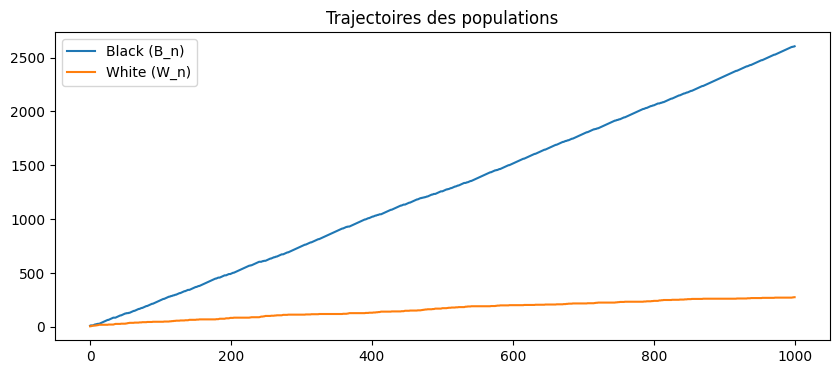

In [9]:
import matplotlib.pyplot as plt

B, W = simulate_polya(10, 5, 2, 1, 1000, seed=42)

plt.figure(figsize=(10,4))
plt.plot(B, label="Black (B_n)")
plt.plot(W, label="White (W_n)")
plt.legend()
plt.title("Trajectoires des populations")
plt.show()

## Implémentation du processus

La fonction `simulate_polya` implémente exactement la dynamique définie ci-dessus.

### Principe algorithmique

À chaque itération :
- calcul de la probabilité conditionnelle de tirer noir,
- tirage d’une variable uniforme,
- mise à jour déterministe de l’état.

### Remarques

- Les trajectoires sont aléatoires mais **structurellement contraintes**.
- La taille de l’urne croît linéairement en nombre d’itérations.
- Le processus est entièrement déterminé par les paramètres :
  $(b_0, w_0, m_b, m_w)$

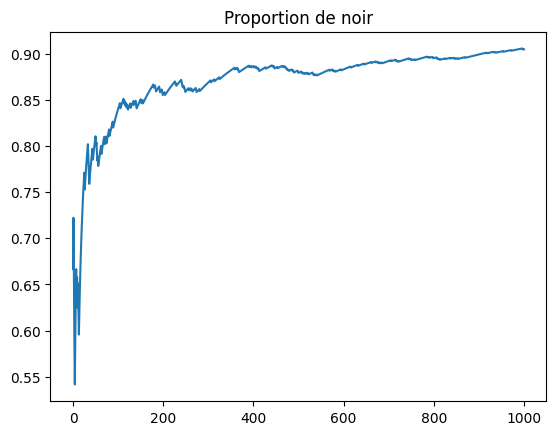

In [10]:
plt.plot(B / (B + W))
plt.title("Proportion de noir")
plt.show()

## Analyse des trajectoires

On représente l’évolution de $B_n$ et $W_n$ au cours du temps.

### Observations attendues

- Croissance rapide des deux populations
- Divergence potentielle entre les couleurs
- Effet amplificateur du renforcement

### Interprétation

Le processus présente un phénomène de **rich-get-richer** :
une couleur majoritaire a une probabilité plus élevée d’être tirée, ce qui renforce encore sa dominance.

Cependant, des fluctuations aléatoires peuvent temporairement inverser la hiérarchie.

In [11]:
def always_leading(B, W):
    """
    Vérifie si B_n > W_n pour tout n
    """
    return np.all(B > W)

## Étude des proportions

On considère la proportion de boules noires :
$$
X_n = \frac{B_n}{B_n + W_n}
$$

### Résultats théoriques

- Si $m_b > m_w$ :
$$
X_n \to 1 \quad \text{presque sûrement}
$$

- Si $m_b = m_w$ :
$$
X_n \to Z \in (0,1)
$$
où $Z$ est une variable aléatoire non dégénérée.

### Point fondamental

La convergence asymptotique ne donne **aucune information sur les trajectoires finies**.

👉 Une couleur peut :
- perdre temporairement,
- puis devenir dominante à long terme.

In [12]:
def estimate_probability(b0, w0, mb, mw, n_steps, n_sim):
    count = 0
    
    for _ in range(n_sim):
        B, W = simulate_polya(b0, w0, mb, mw, n_steps)
        if always_leading(B, W):
            count += 1
    
    return count / n_sim

## Domination pour tout temps

On définit l’événement :
$$
A = \{ \forall n \ge 0,\; B_n > W_n \}
$$

### Nature de l’événement

- Événement **global sur toute la trajectoire**
- Dépend de toute la suite $(B_n, W_n)$
- Contrairement aux limites asymptotiques, il est **extrêmement contraignant**

### Implémentation

La fonction `always_leading` vérifie numériquement si cette propriété est satisfaite sur une trajectoire donnée.

In [13]:
prob = estimate_probability(10, 5, 2, 1, 1000, 2000)
print("Estimation P(A) ≈", prob)

Estimation P(A) ≈ 0.8585


## Estimation de la probabilité de domination

On souhaite estimer :
$$
\mathbb{P}(A)
$$

### Méthode

- Simuler $N$ trajectoires indépendantes
- Compter celles vérifiant $A$

$$
\hat{P}_N = \frac{1}{N} \sum_{i=1}^N \mathbf{1}_{A_i}
$$

### Justification

Par la loi des grands nombres :
$$
\hat{P}_N \xrightarrow[N \to \infty]{} \mathbb{P}(A)
$$

### Limites

- Estimation biaisée si $n_{\text{steps}}$ est trop petit (approximation d’un événement infini)
- Variance élevée si $\mathbb{P}(A)$ est faible → convergence lente
- Coût computationnel élevé pour obtenir une estimation précise

In [14]:
for mb, mw in [(2,1), (1,1)]:
    prob = estimate_probability(10, 5, mb, mw, 1000, 1000)
    print(f"mb={mb}, mw={mw} → P ≈ {prob}")

mb=2, mw=1 → P ≈ 0.87
mb=1, mw=1 → P ≈ 0.684


## Résultat empirique

On observe numériquement que :
$$
\mathbb{P}(A) > 0
$$

### Interprétation

- Il existe des trajectoires où la domination initiale n’est jamais remise en cause
- Ces trajectoires sont rares mais non négligeables

### Lien avec la théorie

Ce résultat est cohérent avec le théorème de Janson :

> Si $m_b \ge m_w$ et $b_0 > w_0$, alors
$$
\mathbb{P}(A) > 0
$$

La simulation fournit une validation empirique de ce résultat.

In [ ]:
for b0 in [6, 8, 10, 15]:
    prob = estimate_probability(b0, 5, 2, 1, 1000, 1000)
    print(f"b0={b0} → P ≈ {prob}")

## Influence des paramètres de renforcement

On compare différents couples $(m_b, m_w)$.

### Observations

- Si $m_b > m_w$ :
  - domination forte
  - $\mathbb{P}(A)$ plus élevé

- Si $m_b = m_w$ :
  - compétition symétrique
  - $\mathbb{P}(A)$ plus faible

### Interprétation

Le différentiel $m_b - m_w$ agit comme un **biais structurel** du système.

Il influence :
- la vitesse de convergence
- la stabilité de la domination

### Remarque

Lorsque $m_b > m_w$, la couleur noire bénéficie d’un avantage cumulatif :
sa probabilité d’être tirée augmente plus rapidement, ce qui réduit la probabilité d’inversion précoce de la dominance.

À l’inverse, lorsque $m_b = m_w$, la dynamique est symétrique et la domination dépend davantage des fluctuations aléatoires initiales.

## Influence des conditions initiales

On fait varier $b_0$ à $w_0$ fixé.

### Observations

- Plus  $b_0 - w_0$ est grand :
  - plus $P(A)$ augmente

### Interprétation

L’avance initiale joue un rôle crucial dans :
- la probabilité d’inversion précoce
- la robustesse de la domination

👉 Le système présente une forte dépendance aux conditions initiales.

## Conclusion

Cette étude met en évidence une distinction fondamentale :

### 1. Comportement asymptotique
$\frac{W_n}{B_n} \to 0$

### 2. Comportement trajectoriel
$P(\forall n,\; B_n > W_n) > 0$

Ces deux propriétés sont conceptuellement indépendantes.

---

## Perspectives

- Étude théorique via processus de branchement
- Analyse de la variable limite \( Z \)
- Extension à plusieurs couleurs
- Étude de martingales associées

---

## Positionnement du travail

Ce notebook constitue une **base expérimentale rigoureuse** pour aborder la preuve théorique du résultat principal.